# Часть 0. Загрузка и предобработка данных

## Шаг 1. Импорты

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

## Шаг 2. Скачивание датасета

Перейдите по ссылке из личного кабинета на Google Таблицу со списком студентов. Найдите своё ФИО в списке и запомните соответствующий порядковый номер. Заполните его в ячейке ниже и выполните ячейку. Если вы не можете найти себя в списке, обратитесь к своему преподавателю.

In [40]:
### BEGIN YOUR CODE

Student_ID = 22

### END YOUR CODE

Теперь выполните следующую ячейку. Она вычислит номер задания и выведет его.

In [41]:
datasets = [
    (
        'Combined Cycle Power Plant',
        'https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant',
        'PE',
        85, 15
    ),
    (
        'Beijing PM2.5',
        'https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data',
        'pm2.5',
        80, 20
    ),
    (
        'Airfoil Self-Noise',
        'https://archive.ics.uci.edu/dataset/291/airfoil+self+noise',
        'scaled-sound-pressure',
        90, 10
    ),
    (
        'Energy Efficiency',
        'https://archive.ics.uci.edu/dataset/242/energy+efficiency',
        'Y1, Y2 (здесь две целевые переменные)',
        90, 10
    ),
    (
        'Bike Sharing',
        'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset',
        'cnt',
        90, 10
    ),
    (
        'Forest Fires',
        'https://archive.ics.uci.edu/dataset/162/forest+fires',
        'area',
        90, 10
    ),
    (
        'Concrete Compressive Strength',
        'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength',
        'Concrete compressive strength',
        90, 10
    )
]

dataset_id = None if Student_ID is None else (Student_ID - 1) % len(datasets)
if dataset_id is None:
    print("ОШИБКА! Не указан порядковый номер студента в списке группы.")
else:
    print(f"Информация о датасете '{datasets[dataset_id][0]}' доступна по следующей ссылке: {datasets[dataset_id][1]}")
    print(f"Целевая переменная: {datasets[dataset_id][2]}")
    print(f"Разделение выборки на train+val/test: {datasets[dataset_id][3]}%/{datasets[dataset_id][4]}%")

Информация о датасете 'Combined Cycle Power Plant' доступна по следующей ссылке: https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant
Целевая переменная: PE
Разделение выборки на train+val/test: 85%/15%


## Шаг 3. Загрузка и обработка датасета

Скачайте датасет по ссылке выше и считайте его в датафрейм `df`.

Большинство датасетов можно загрузить через `pd.read_csv(...)`. Если файл архивирован — распакуйте его вручную или воспользуйтесь `zipfile` / `requests`.

In [42]:
import subprocess
import sys

# Установка ucimlrepo
subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo", "-q"])

from ucimlrepo import fetch_ucirepo

# Загрузка датасета
combined_cycle_power_plant = fetch_ucirepo(id=294)
df = pd.concat([combined_cycle_power_plant.data.features,
                combined_cycle_power_plant.data.targets], axis=1)
print("Датасет загружен!")
print(f"Размер: {df.shape}")

Датасет загружен!
Размер: (9568, 5)


Обработайте датасет. В обработке вы имеете почти полную свободу — важно побить бейзлайн.

**Что НЕОБХОДИМО сделать** (иначе тесты не пройдут):
- Обработать пропуски (удалить строки / заполнить средним / медианой — на ваш выбор)
- Закодировать категориальные признаки (например, `pd.get_dummies` или `LabelEncoder`)

**Что ПОЛЕЗНО сделать** (помогает побить бейзлайн):
- Удалить дубликаты
- Обработать выбросы
- Удалить признаки с низкой информативностью (посмотрите на корреляции)
- Добавить новые признаки (feature engineering)
- Стандартизировать числовые признаки

> **Подсказка:** [sklearn.preprocessing](https://scikit-learn.org/stable/api/sklearn.preprocessing.html) содержит `StandardScaler`, `MinMaxScaler`, `LabelEncoder`, `OneHotEncoder` и другие полезные инструменты.

> ⚠️ **Важно про стандартизацию целевой переменной:** если вы стандартизируете `y`, перед сохранением результатов в `y_pred_*` нужно вернуть предсказания к исходному масштабу. Иначе MAPE будет считаться неверно и тесты провалятся. Сохраните параметры стандартизации (`mean`, `std`) для обратного преобразования.

**ВАЖНО:** обработанный по обязательным пунктам датафрейм запишите в `df_base`, дополнительно улучшенный — в `df_processed`. Не перезаписывайте эти переменные и `df`.

In [43]:
### BEGIN YOUR CODE
print("Исходный датасет:")
print(f"Размер: {df.shape}")
print(f"Пропуски:\n{df.isnull().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")
df_base = df.copy()
categorical_cols = df_base.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    print(f"Категориальные признаки: {list(categorical_cols)}")
    # Применяем one-hot encoding
    df_base = pd.get_dummies(df_base, columns=categorical_cols, drop_first=True)
    print("Категориальные признаки закодированы")
else:
    print("Категориальных признаков нет")

Исходный датасет:
Размер: (9568, 5)
Пропуски:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64
Дубликаты: 41
Категориальных признаков нет


In [44]:
### BEGIN YOUR CODE
df_processed = df_base.copy()
# 1. Удаление дубликатов (если есть)
initial_shape = df_processed.shape
df_processed = df_processed.drop_duplicates()
print(f"\nУдалено дубликатов: {initial_shape[0] - df_processed.shape[0]}")
# 2. Обработка выбросов (метод IQR)
Q1 = df_processed.quantile(0.25)
Q3 = df_processed.quantile(0.75)
IQR = Q3 - Q1

# Определяем выбросы
outliers_mask = ((df_processed < (Q1 - 1.5 * IQR)) | (df_processed > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"Количество выбросов: {outliers_mask.sum()}")

# Удаляем выбросы
df_processed = df_processed[~outliers_mask]
print(f"Размер после удаления выбросов: {df_processed.shape}")
print(f"\ndf_base shape: {df_base.shape}")
print(f"df_processed shape (без стандартизации): {df_processed.shape}")
# Полиномиальные признаки (квадраты)
df_processed['AT_sq'] = df_processed['AT'] ** 2
df_processed['V_sq'] = df_processed['V'] ** 2
df_processed['AP_sq'] = df_processed['AP'] ** 2
df_processed['RH_sq'] = df_processed['RH'] ** 2

# Взаимодействия между признаками
df_processed['AT_V'] = df_processed['AT'] * df_processed['V']
df_processed['AT_AP'] = df_processed['AT'] * df_processed['AP']
df_processed['AT_RH'] = df_processed['AT'] * df_processed['RH']
df_processed['V_AP'] = df_processed['V'] * df_processed['AP']
df_processed['V_RH'] = df_processed['V'] * df_processed['RH']
df_processed['AP_RH'] = df_processed['AP'] * df_processed['RH']

print(f"После добавления признаков: {df_processed.shape}")
### END YOUR CODE


Удалено дубликатов: 41
Количество выбросов: 104
Размер после удаления выбросов: (9423, 5)

df_base shape: (9568, 5)
df_processed shape (без стандартизации): (9423, 5)
После добавления признаков: (9423, 15)


# Часть 1. Линейная регрессия (scikit-learn)

## Что такое линейная регрессия?

Линейная регрессия — это модель, которая предсказывает числовое значение `y` как **линейную комбинацию признаков** `x`:

$$y = \mathbf{x} \boldsymbol{\theta} + \theta_0$$

где $\boldsymbol{\theta}$ — вектор весов (коэффициентов), $\theta_0$ — свободный член (смещение, bias/intercept).

**Как модель обучается?** Она подбирает $\boldsymbol{\theta}$ и $\theta_0$ так, чтобы минимизировать **полную функцию потерь** (функционал качества, эмпирический риск). Чаще всего используют **MSE (Mean Squared Error)**:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Чем меньше MSE — тем ближе предсказания к реальным значениям.

**Как оценивать качество?** В этой работе используется **MAPE (Mean Absolute Percentage Error)**:

$$\text{MAPE} = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

MAPE удобна тем, что выражается в процентах: MAPE = 0.05 означает среднюю ошибку 5%. Она позволяет сравнивать качество моделей на разных датасетах с разными масштабами целевой переменной.

## Шаг 1. Разделение на train / val / test

**Зачем три выборки?**

| Выборка | Назначение |
|---------|------------|
| **Train** | Обучение модели (подбор весов) |
| **Val (validation)** | Подбор гиперпараметров (например, скорость обучения, количество эпох) без «подглядывания» в тест |
| **Test** | Финальная оценка качества — трогается **только один раз** в самом конце |

Если настраивать гиперпараметры сразу по test, то модель фактически «видит» тестовые данные и реальная ошибка на новых данных окажется хуже.

> **Размер test-выборки** указан в вашем варианте задания (выше, рядом со ссылкой на датасет). Используйте `train_test_split` из sklearn.

In [45]:
### BEGIN YOUR CODE

# Разделите df_base и df_processed на матрицу признаков X и вектор целевой переменной y
X_base = df_base.drop(columns=['PE'])
y_base = df_base['PE']

X_processed = df_processed.drop(columns=['PE'])
y_processed = df_processed['PE']

### END YOUR CODE

print("Разделение данных выполнено:")
print(f"X_base shape: {X_base.shape}")
print(f"y_base shape: {y_base.shape}")
print(f"X_processed shape: {X_processed.shape}")
print(f"y_processed shape: {y_processed.shape}")

Разделение данных выполнено:
X_base shape: (9568, 4)
y_base shape: (9568,)
X_processed shape: (9423, 14)
y_processed shape: (9423,)


In [46]:
from sklearn.model_selection import train_test_split

### BEGIN YOUR CODE

# Для base: только train и test (val не нужен, гиперпараметров нет)
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.15, random_state=42
)

### END YOUR CODE

print("Разделение для df_base выполнено:")
print(f"X_train_base: {X_train_base.shape}")
print(f"X_test_base:  {X_test_base.shape}")
print(f"y_train_base: {y_train_base.shape}")
print(f"y_test_base:  {y_test_base.shape}")

Разделение для df_base выполнено:
X_train_base: (8132, 4)
X_test_base:  (1436, 4)
y_train_base: (8132,)
y_test_base:  (1436,)


In [47]:
### BEGIN YOUR CODE

# Для processed: сначала отделить test, затем из оставшегося выделить val
X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(
    X_processed, y_processed, test_size=0.15, random_state=42
)

X_train_processed, X_val_processed, y_train_processed, y_val_processed = train_test_split(
    X_train_processed, y_train_processed, test_size=0.15, random_state=42
)

### END YOUR CODE

print("Разделение для df_processed выполнено:")
print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_val_processed:   {X_val_processed.shape}")
print(f"X_test_processed:  {X_test_processed.shape}")
print(f"y_train_processed: {y_train_processed.shape}")
print(f"y_val_processed:   {y_val_processed.shape}")
print(f"y_test_processed:  {y_test_processed.shape}")

Разделение для df_processed выполнено:
X_train_processed: (6807, 14)
X_val_processed:   (1202, 14)
X_test_processed:  (1414, 14)
y_train_processed: (6807,)
y_val_processed:   (1202,)
y_test_processed:  (1414,)


In [48]:
# Промежуточная проверка — убедитесь, что размеры выглядят разумно
print("Base:")
print(f"  X_train_base:    {X_train_base.shape}")
print(f"  X_test_base:     {X_test_base.shape}")
print()
print("Processed:")
print(f"  X_train_processed: {X_train_processed.shape}")
print(f"  X_val_processed:   {X_val_processed.shape}")
print(f"  X_test_processed:  {X_test_processed.shape}")

Base:
  X_train_base:    (8132, 4)
  X_test_base:     (1436, 4)

Processed:
  X_train_processed: (6807, 14)
  X_val_processed:   (1202, 14)
  X_test_processed:  (1414, 14)


## Шаг 2. Обучение линейной регрессии

Ниже приведён **бейзлайн** — простейшая линейная регрессия без какой-либо дополнительной обработки данных. Ваша задача — **побить его**, то есть получить `MAPE(y_pred_processed) < MAPE(y_pred_base)`.

Для этого используйте `df_processed` и экспериментируйте с:
- предобработкой данных (стандартизация, удаление выбросов, feature engineering)
- подбором гиперпараметров на `val`-выборке

> **Подсказка:** гиперпараметры подбираются на val, финальная оценка считается на test. Не оптимизируйте напрямую по test!

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

In [50]:
def baseline():
    """Бейзлайн: LinearRegression без предобработки, обученный на base-данных."""
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_base, y_train_base)
    return lin_reg.predict(X_test_base)

In [51]:
y_pred_base = baseline()
print(f"Baseline MAPE: {mean_absolute_percentage_error(y_test_base, y_pred_base):.4f}")

Baseline MAPE: 0.0079


Обучите улучшенную модель и запишите предсказания на тестовой выборке в `y_pred_processed`.

In [52]:
### BEGIN YOUR CODE

# Обучаем LinearRegression на обработанных данных
lin_reg_processed = LinearRegression()
lin_reg_processed.fit(X_train_processed, y_train_processed)

# Предсказываем на тестовой выборке
y_pred_processed = lin_reg_processed.predict(X_test_processed)

### END YOUR CODE

print(f"Processed MAPE: {mean_absolute_percentage_error(y_test_processed, y_pred_processed):.4f}")
print(f"Baseline MAPE:  {mean_absolute_percentage_error(y_test_base, y_pred_base):.4f}")

Processed MAPE: 0.0071
Baseline MAPE:  0.0079


# Часть 2. Градиентный спуск (numpy)

## Что такое градиентный спуск?

Представьте, что полная функция потерь — это холмистый ландшафт, а мы стоим на нём и хотим спуститься в самую низкую точку (минимум). Градиент указывает направление наибольшего **роста** функции, поэтому мы идём в противоположном направлении:

$$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta \cdot \nabla_{\boldsymbol{\theta}} Q$$

где $\eta$ — **learning rate** (размер шага), $\nabla_{\boldsymbol{\theta}} Q$ — градиент полной функции потерь по весам.

**Стохастический** мини-батчевый градиентный спуск (SGD) отличается тем, что градиент вычисляется не на всей выборке, а на случайном **мини-батче** — случайной подвыборке небольшого размера. Это быстрее и часто сходится лучше.

---

### Градиенты MSE для линейной модели

Формулы градиентов $\dfrac{\partial Q}{\partial \boldsymbol{\theta}}$ и $\dfrac{\partial Q}{\partial \theta_0}$ для модели $\hat{y} = X\boldsymbol{\theta} + \theta_0$ и полной функции потерь $Q = \frac{1}{n}\|\hat{y} - y\|^2$ выводятся в теоретической части (вопрос Q1).

Именно их нужно реализовать в методе `step()` класса `CustomSGD`.

> **Интерфейс:** `CustomSGD.__init__(params, lr)` принимает список параметров модели `[W, b]` и хранит их как атрибут, где `W` — "веса" модели, т.е. параметры $\boldsymbol{\theta}$; а `b` — смещение $\theta_0$. Метод `step(x_batch, y_batch)` вычисляет градиенты и обновляет параметры **in-place** (через `params[0] -= ...`).

## Шаг 1. Реализация CustomSGD

In [53]:
### BEGIN YOUR CODE
class CustomSGD:
    def __init__(self, params, lr):
        """
        params: список параметров модели, например [W, b]
                Изменения в params автоматически отражаются в модели,
                поэтому достаточно хранить ссылку на этот список.
        lr: learning rate (скорость обучения), положительное число
        """
        self.params = params
        self.lr = lr

    def step(self, x_batch, y_batch):
        """
        Один шаг SGD: вычислить градиенты MSE на батче и обновить params in-place.

        x_batch: numpy array размера (batch_size, n_features)
        y_batch: numpy array размера (batch_size,)
        """
        # Получаем текущие параметры
        W, b = self.params[0], self.params[1]

        # Количество образцов в батче
        n = len(y_batch)

        # Убеждаемся, что W - 1D массив
        if W.ndim > 1:
            W = W.flatten()
            self.params[0] = W  # обновляем ссылку

        # Предсказание: y_pred = X @ W + b
        y_pred = x_batch @ W + b

        # Ошибка
        error = y_pred - y_batch

        # Градиенты MSE
        dW = (2.0 / n) * x_batch.T @ error
        db = (2.0 / n) * np.sum(error)

        # Обновление параметров in-place
        self.params[0] -= self.lr * dW
        self.params[1] -= self.lr * db
### END YOUR CODE

# Часть 3. Линейная регрессия (numpy)

## Шаг 1. Реализация CustomLinearRegression

Реализуйте класс линейной регрессии на numpy. Класс должен поддерживать два режима обучения, задаваемых параметром `solver`:

- `solver='SGD'` — обучение через `CustomSGD` (стохастический градиентный спуск)
- `solver='MNK'` — обучение методом наименьших квадратов (аналитическое решение)

**Метод наименьших квадратов (МНК)** даёт точное решение задачи минимизации MSE без итераций:

$$\boldsymbol{\theta} = (X^\top X)^{-1} X^\top y$$

Для его реализации удобно расширить матрицу признаков столбцом единиц (`np.hstack([X, np.ones(...)])`), тогда последний элемент вектора весов будет соответствовать свободному члену $b$.

При реализации через numpy используйте `np.linalg.solve(A, b)` (вместо явного обращения матрицы через `np.linalg.inv`) — это устойчивее численно.

> **Бонусный параметр** (для бонусного задания *): `regularization` задаёт тип регуляризации (`'ridge'` или `'lasso'`), `tau` — её коэффициент.

In [69]:
class CustomLinearRegression:
    def __init__(self, solver='SGD', regularization=None, tau=0.01):
        self.solver = solver
        self.regularization = regularization
        self.tau = tau
        self.W = None
        self.b = None
        self.learning_rate = 0.01
        self.X_mean = None
        self.X_std = None
        self.y_mean = None
        self.y_std = None

    def _standardize(self, X, y=None, fit=True):
        """Стандартизация данных"""
        if fit:
            self.X_mean = np.mean(X, axis=0)
            self.X_std = np.std(X, axis=0)
            self.X_std[self.X_std == 0] = 1
            X_scaled = (X - self.X_mean) / self.X_std

            if y is not None:
                self.y_mean = np.mean(y)
                self.y_std = np.std(y)
                if self.y_std == 0:
                    self.y_std = 1
                y_scaled = (y - self.y_mean) / self.y_std
                return X_scaled, y_scaled
            return X_scaled
        else:
            X_scaled = (X - self.X_mean) / self.X_std
            return X_scaled

    def _inverse_standardize(self, y_scaled):
        """Обратное преобразование"""
        return y_scaled * self.y_std + self.y_mean

    def fit(self, X, y):
        if hasattr(y, 'values'):
            y = y.values
        y = y.ravel()

        if hasattr(X, 'values'):
            X = X.values

        # СТАНДАРТИЗИРУЕМ ДАННЫЕ
        X_scaled, y_scaled = self._standardize(X, y, fit=True)

        if self.solver == 'MNK':
            n_samples, n_features = X_scaled.shape
            X_with_bias = np.hstack([X_scaled, np.ones((n_samples, 1))])
            XTX = X_with_bias.T @ X_with_bias
            XTy = X_with_bias.T @ y_scaled
            theta = np.linalg.solve(XTX, XTy)
            self.W = theta[:-1]
            self.b = theta[-1]

        elif self.solver == 'SGD':
            n_samples, n_features = X_scaled.shape

            self.W = np.zeros(n_features)
            self.b = 0.0

            n_epochs = 500
            batch_size = 32
            lr = self.learning_rate

            for epoch in range(n_epochs):
                indices = np.random.permutation(n_samples)
                X_shuffled = X_scaled[indices]
                y_shuffled = y_scaled[indices]

                for i in range(0, n_samples, batch_size):
                    X_batch = X_shuffled[i:i+batch_size]
                    y_batch = y_shuffled[i:i+batch_size]

                    y_pred = X_batch @ self.W + self.b
                    error = y_pred - y_batch
                    n = len(y_batch)

                    dW = (2.0 / n) * X_batch.T @ error
                    db = (2.0 / n) * np.sum(error)

                    if self.regularization == 'ridge':
                        dW += self.tau * self.W
                    elif self.regularization == 'lasso':
                        dW += self.tau * np.sign(self.W)

                    self.W -= lr * dW
                    self.b -= lr * db

    def predict(self, X):
        if self.W is None or self.b is None:
            raise RuntimeError("Model not fitted yet")
        if hasattr(X, 'values'):
            X = X.values

        # Стандартизируем X
        X_scaled = self._standardize(X, fit=False)

        # Предсказываем в стандартизованном масштабе
        y_pred_scaled = X_scaled @ self.W + self.b

        # Возвращаем в исходный масштаб
        return self._inverse_standardize(y_pred_scaled)

## Шаг 2. Обучение CustomLinearRegression с помощью SGD

Обучите модель с помощью `CustomSGD` и запишите предсказания на тестовой выборке в `y_pred_custom`.

**Что нужно сделать:**
1. Инициализировать параметры модели `W` и `b`
2. Реализовать мини-батчевый обучающий цикл (эпохи → батчи → шаг оптимизатора) — он ляжет в основу `fit()` в `CustomLinearRegression`, но здесь дополнительно отслеживается val loss
3. На каждой эпохе сохранять средний MSE на train и val выборках
4. После обучения построить графики функции потерь на train и val выборках
5. Вычислить MAPE на тестовой выборке и сравнить с sklearn-бейзлайном

Ниже приведён шаблон обучающего цикла — заполните недостающие части.

Epoch 10/100, Train Loss: 0.066477, Val Loss: 0.071900
Epoch 20/100, Train Loss: 0.064815, Val Loss: 0.070654
Epoch 30/100, Train Loss: 0.064314, Val Loss: 0.070432
Epoch 40/100, Train Loss: 0.064099, Val Loss: 0.069975
Epoch 50/100, Train Loss: 0.064106, Val Loss: 0.070664
Epoch 60/100, Train Loss: 0.064045, Val Loss: 0.070055
Epoch 70/100, Train Loss: 0.064158, Val Loss: 0.069923
Epoch 80/100, Train Loss: 0.064022, Val Loss: 0.069764
Epoch 90/100, Train Loss: 0.063841, Val Loss: 0.070374
Epoch 100/100, Train Loss: 0.063995, Val Loss: 0.069991


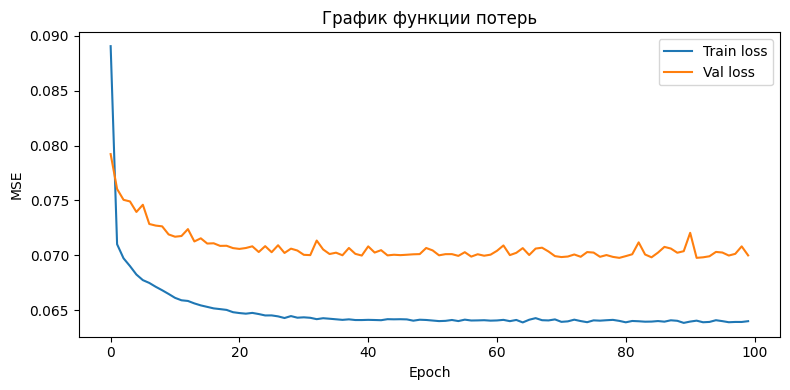

In [55]:
# Перед обучением добавь стандартизацию
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_processed)
X_val_scaled = scaler_X.transform(X_val_processed)
X_test_scaled = scaler_X.transform(X_test_processed)

y_train_scaled = scaler_y.fit_transform(y_train_processed.values.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val_processed.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test_processed.values.reshape(-1, 1)).ravel()

n_epochs = 100
batch_size = 32
learning_rate = 0.01  # Для стандартизированных данных 0.01 - нормально

### BEGIN YOUR CODE

# Инициализируйте параметры модели (веса и bias)
n_features = X_train_scaled.shape[1]
W = np.zeros(n_features)  # размер (n_features,)
b = 0.0  # скаляр
params = [W, b]

optimizer = CustomSGD(params, lr=learning_rate)

train_losses = []
val_losses = []

# Используем SCALED версии данных!
X_train_np = X_train_scaled
y_train_np = y_train_scaled
X_val_np = X_val_scaled
y_val_np = y_val_scaled

for epoch in range(n_epochs):
    # 1. Перемешайте индексы тренировочных данных
    n_samples = len(X_train_np)
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train_np[indices]
    y_shuffled = y_train_np[indices]

    # 2. Разбейте на батчи размером batch_size
    epoch_loss = 0
    n_batches = 0

    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        # 3. Для каждого батча сделайте шаг оптимизатора
        optimizer.step(X_batch, y_batch)

        # Вычисляем loss на батче для отслеживания
        y_pred_batch = X_batch @ W + b
        batch_loss = np.mean((y_pred_batch - y_batch) ** 2)
        epoch_loss += batch_loss
        n_batches += 1

    # Средний loss за эпоху
    epoch_loss = epoch_loss / n_batches
    train_losses.append(epoch_loss)

    # Вычислите val loss
    y_val_pred = X_val_np @ W + b
    val_loss = np.mean((y_val_pred - y_val_np) ** 2)
    val_losses.append(val_loss)

    # Выводим прогресс каждые 10 эпох
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {epoch_loss:.6f}, Val Loss: {val_loss:.6f}")

### END YOUR CODE

# График функции потерь
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('График функции потерь')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
### BEGIN YOUR CODE

# Предсказания на тестовой выборке (в стандартизованном масштабе)
X_test_np = X_test_scaled
y_pred_custom_scaled = X_test_np @ W + b

# Возвращаем к исходному масштабу (мегаватты)
y_pred_custom = scaler_y.inverse_transform(y_pred_custom_scaled.reshape(-1, 1)).ravel()

### END YOUR CODE

print(f"Custom SGD MAPE: {mean_absolute_percentage_error(y_test_processed, y_pred_custom):.4f}")
print(f"Baseline MAPE:   {mean_absolute_percentage_error(y_test_base, y_pred_base):.4f}")

Custom SGD MAPE: 0.0073
Baseline MAPE:   0.0079


## Шаг 3. Метод наименьших квадратов (МНК)

Обучите `CustomLinearRegression` с `solver='MNK'` на вашем датасете.

МНК даёт **точное** решение без итераций — это удобно для небольших датасетов. На очень больших данных инвертирование матрицы $(X^\top X)$ может быть медленным или численно нестабильным — в таком случае возьмите случайную долю данных.

Сравните результаты МНК с SGD: они должны быть близкими (теоретически МНК — глобальный минимум MSE).

Запишите предсказания в `y_pred_mnk`.

In [57]:
### BEGIN YOUR CODE

# Используем реализованный класс CustomLinearRegression с solver='MNK'
model_mnk = CustomLinearRegression(solver='MNK')
model_mnk.fit(X_train_scaled, y_train_scaled)

# Предсказываем (в стандартизованном масштабе)
y_pred_mnk_scaled = model_mnk.predict(X_test_scaled)

# Возвращаем к исходному масштабу (мегаватты)
y_pred_mnk = scaler_y.inverse_transform(y_pred_mnk_scaled.reshape(-1, 1)).ravel()

### END YOUR CODE

print(f"МНК MAPE:      {mean_absolute_percentage_error(y_test_processed, y_pred_mnk):.4f}")
print(f"Custom SGD MAPE: {mean_absolute_percentage_error(y_test_processed, y_pred_custom):.4f}")
print(f"Baseline MAPE:   {mean_absolute_percentage_error(y_test_base, y_pred_base):.4f}")

МНК MAPE:      0.0071
Custom SGD MAPE: 0.0073
Baseline MAPE:   0.0079


In [58]:
# Проверка реализации МНК
sk_model = LinearRegression().fit(X_train_processed, y_train_processed)
y_pred_sk = sk_model.predict(X_test_processed)

assert np.allclose(y_pred_mnk, y_pred_sk, atol=1e-4), \
    "Проверьте реализацию МНК: предсказания расходятся с эталонной реализацией sklearn."
print("✓ МНК реализован корректно")

✓ МНК реализован корректно


# Бонус *. Регуляризация (Ridge и LASSO) [+10 баллов]

**Зачем нужна регуляризация?**

Модель может переобучиться: идеально подстроиться под тренировочные данные, но плохо работать на новых. Регуляризация добавляет к функции потерь **штраф за большие веса**, что вынуждает модель оставаться проще.

**Ridge (L2-регуляризация):**

$$Q_{\text{Ridge}} = \text{MSE} + \tau \|\boldsymbol{\theta}\|_2^2 = \text{MSE} + \tau \sum_j \theta_j^2$$

**LASSO (L1-регуляризация):**

$$Q_{\text{LASSO}} = \text{MSE} + \tau \|\boldsymbol{\theta}\|_1 = \text{MSE} + \tau \sum_j |\theta_j|$$

LASSO обнуляет незначимые веса (делает модель разреженной), Ridge лишь уменьшает их.

Дополнительные слагаемые в градиенте выводятся в теоретической части (вопрос Q2). Используйте их при реализации шага SGD с регуляризацией.

**Что нужно сделать:** добавить поддержку регуляризации в `CustomLinearRegression`. Интерфейс:

```python
model_ridge = CustomLinearRegression(solver='SGD', regularization='ridge', tau=0.01)
model_lasso = CustomLinearRegression(solver='SGD', regularization='lasso', tau=0.01)
```

Запишите предсказания в `y_pred_ridge` и `y_pred_lasso`.

In [70]:
### BEGIN YOUR CODE

# Ridge
model_ridge = CustomLinearRegression(solver='SGD', regularization='ridge', tau=0.001)
model_ridge.learning_rate = 0.01
model_ridge.fit(X_train_processed, y_train_processed)
y_pred_ridge = model_ridge.predict(X_test_processed)

# LASSO
model_lasso = CustomLinearRegression(solver='SGD', regularization='lasso', tau=0.0001)
model_lasso.learning_rate = 0.01
model_lasso.fit(X_train_processed, y_train_processed)
y_pred_lasso = model_lasso.predict(X_test_processed)

### END YOUR CODE

print(f"Ridge MAPE:    {mean_absolute_percentage_error(y_test_processed, y_pred_ridge):.6f}")
print(f"LASSO MAPE:    {mean_absolute_percentage_error(y_test_processed, y_pred_lasso):.6f}")
print(f"Baseline MAPE: {mean_absolute_percentage_error(y_test_base, y_pred_base):.6f}")

Ridge MAPE:    0.007274
LASSO MAPE:    0.007255
Baseline MAPE: 0.007870


# Бонус **. Оптимизатор Adam [+20 баллов]

Adam (Adaptive Moment Estimation) — улучшение SGD, которое адаптирует learning rate для каждого параметра отдельно. Он комбинирует идеи **Momentum** (накопление градиентов) и **RMSProp** (нормировка по скользящей дисперсии):

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{(первый момент)}$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{(второй момент)}$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \quad \text{(коррекция смещения)}$$
$$\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} - \eta \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}$$

Типичные значения гиперпараметров: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$.

Реализуйте `CustomAdam` и обучите `CustomLinearRegression` с его помощью. Запишите предсказания в `y_pred_adam`.

In [60]:
class CustomAdam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        ### BEGIN YOUR CODE
        self.params = params  # список [W, b]
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        # Инициализация моментов
        self.m = [np.zeros_like(p) for p in params]  # первый момент (mean)
        self.v = [np.zeros_like(p) for p in params]  # второй момент (uncentered variance)
        self.t = 0  # шаг времени
        ### END YOUR CODE

    def step(self, x_batch, y_batch):
        ### BEGIN YOUR CODE
        # Получаем текущие параметры
        W, b = self.params[0], self.params[1]

        # Количество образцов в батче
        n = len(y_batch)

        # Предсказание
        if W.ndim == 1:
            y_pred = x_batch @ W + b
        else:
            y_pred = x_batch @ W.flatten() + b

        # Ошибка
        error = y_pred - y_batch

        # Градиенты
        dW = (2.0 / n) * x_batch.T @ error
        db = (2.0 / n) * np.sum(error)

        # Увеличиваем счётчик шагов
        self.t += 1

        # Обновляем моменты для W
        self.m[0] = self.beta1 * self.m[0] + (1 - self.beta1) * dW
        self.v[0] = self.beta2 * self.v[0] + (1 - self.beta2) * (dW ** 2)

        # Обновляем моменты для b
        self.m[1] = self.beta1 * self.m[1] + (1 - self.beta1) * db
        self.v[1] = self.beta2 * self.v[1] + (1 - self.beta2) * (db ** 2)

        # Коррекция смещения
        m_hat_W = self.m[0] / (1 - self.beta1 ** self.t)
        v_hat_W = self.v[0] / (1 - self.beta2 ** self.t)
        m_hat_b = self.m[1] / (1 - self.beta1 ** self.t)
        v_hat_b = self.v[1] / (1 - self.beta2 ** self.t)

        # Обновление параметров
        self.params[0] -= self.lr * m_hat_W / (np.sqrt(v_hat_W) + self.eps)
        self.params[1] -= self.lr * m_hat_b / (np.sqrt(v_hat_b) + self.eps)
        ### END YOUR CODE

Обучите `CustomLinearRegression` с помощью `CustomAdam` (аналогично шагу 2 части 3).

In [61]:
### BEGIN YOUR CODE

# Используем Adam оптимизатор
n_epochs = 100
batch_size = 32
learning_rate = 0.001  # для Adam можно чуть больше, чем для SGD

# Инициализация параметров
n_features = X_train_scaled.shape[1]
W = np.zeros(n_features)
b = 0.0
params = [W, b]

# Создаём Adam оптимизатор
optimizer = CustomAdam(params, lr=learning_rate)

train_losses = []
val_losses = []

# Преобразуем данные в numpy
X_train_np = X_train_scaled if hasattr(X_train_scaled, 'shape') else X_train_scaled.values
y_train_np = y_train_scaled if hasattr(y_train_scaled, 'shape') else y_train_scaled.values
X_val_np = X_val_scaled if hasattr(X_val_scaled, 'shape') else X_val_scaled.values
y_val_np = y_val_scaled if hasattr(y_val_scaled, 'shape') else y_val_scaled.values

for epoch in range(n_epochs):
    # Перемешиваем данные
    n_samples = len(X_train_np)
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train_np[indices]
    y_shuffled = y_train_np[indices]

    epoch_loss = 0
    n_batches = 0

    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        # Шаг Adam
        optimizer.step(X_batch, y_batch)

        # Вычисляем loss
        y_pred_batch = X_batch @ W + b
        batch_loss = np.mean((y_pred_batch - y_batch) ** 2)
        epoch_loss += batch_loss
        n_batches += 1

    epoch_loss = epoch_loss / n_batches
    train_losses.append(epoch_loss)

    # Val loss
    y_val_pred = X_val_np @ W + b
    val_loss = np.mean((y_val_pred - y_val_np) ** 2)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {epoch_loss:.6f}, Val Loss: {val_loss:.6f}")

# Предсказания
X_test_np = X_test_scaled if hasattr(X_test_scaled, 'shape') else X_test_scaled.values
y_pred_adam_scaled = X_test_np @ W + b

# Возвращаем к исходному масштабу
y_pred_adam = scaler_y.inverse_transform(y_pred_adam_scaled.reshape(-1, 1)).ravel()
y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

### END YOUR CODE

print(f"Adam MAPE:     {mean_absolute_percentage_error(y_test_original, y_pred_adam):.6f}")
print(f"Baseline MAPE: {mean_absolute_percentage_error(y_test_base, y_pred_base):.6f}")

Epoch 10/100, Train Loss: 0.070177, Val Loss: 0.074772
Epoch 20/100, Train Loss: 0.067025, Val Loss: 0.071761
Epoch 30/100, Train Loss: 0.065925, Val Loss: 0.070589
Epoch 40/100, Train Loss: 0.065304, Val Loss: 0.070496
Epoch 50/100, Train Loss: 0.065249, Val Loss: 0.070016
Epoch 60/100, Train Loss: 0.065197, Val Loss: 0.070031
Epoch 70/100, Train Loss: 0.065396, Val Loss: 0.070077
Epoch 80/100, Train Loss: 0.065066, Val Loss: 0.069973
Epoch 90/100, Train Loss: 0.065169, Val Loss: 0.070025
Epoch 100/100, Train Loss: 0.065047, Val Loss: 0.070064
Adam MAPE:     0.007283
Baseline MAPE: 0.007870
